# Mean daily source water dynamics

In [1]:
import xarray as xr
import datetime as dt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [2]:
data = pd.read_csv('/ocean/rbeutel/MOAD/analysis-becca/projections/combineddata.csv')

In [5]:
data

,Unnamed: 0,year,start,end,section,Idepth,Fdepth,lon,lat,transport,salt
0,0,2014.0,2408.0,2306.277573,2.0,16.192689,3.438488,-124.547978,47.468866,303.159669,31.105961
1,1,2014.0,2408.0,2319.785245,2.0,19.699151,1.907283,-124.472854,47.468866,248.254126,29.523134
2,2,2014.0,2409.0,2306.272426,2.0,-0.364622,7.402451,-124.550437,47.468866,55.977753,31.234024
3,3,2014.0,2409.0,2193.241038,2.0,-0.359163,10.930170,-124.495305,47.468866,130.880503,32.200840
4,4,2014.0,2409.0,0.500000,NaN,-0.350988,0.000000,-125.554054,47.710966,164.057376,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
12906859,12906859,2023.0,2880.0,2744.543902,0.0,94.831099,33.527072,-124.379045,48.489580,301.456764,32.108730
12906860,12906860,2023.0,2880.0,2787.989060,0.0,68.709381,42.144712,-124.379045,48.494390,310.652780,32.161076
12906861,12906861,2023.0,2880.0,2822.958174,0.0,50.886433,22.345608,-124.379045,48.410228,318.123523,31.888180
12906862,12906862,2023.0,2880.0,2769.931399,0.0,37.625616,29.028931,-124.379045,48.495056,157.253209,31.997681


In [41]:
def wm_day_divide(mydata):
    # organize ariane results into daily volume contribution from each water mass 
    start = 2401
    length =int((np.max(mydata.init_t)-start+1)/24)

    bdy_loo = 0
    bdy_sou = 2
    bdy_off = 3
    bdy_nor = 4

    saltdiv = 32
    sdiv = 33.5

    fresh = [np.sum(mydata.final_transp[(mydata.final_section==bdy_sou) & (mydata.final_salt < saltdiv) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 
             if len(mydata.final_transp[(mydata.final_section==bdy_sou) & (mydata.final_salt < saltdiv) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)])>0 
             else 0 
            for i in range(length)]
    cuc = [np.sum(mydata.final_transp[(mydata.final_section==bdy_sou) & (mydata.final_salt >= sdiv) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 for i in range(length)]
    south = [np.sum(mydata.final_transp[(mydata.final_section==bdy_sou) & (mydata.final_salt >= saltdiv) & (mydata.final_salt < sdiv)  & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 
             if len(mydata.final_transp[(mydata.final_section==bdy_sou) & (mydata.final_salt >= saltdiv) & (mydata.final_salt < sdiv)  & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]) > 0
             else 0
             for i in range(length)]
    north = [np.sum(mydata.final_transp[(mydata.final_section==bdy_nor) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 
             if len(mydata.final_transp[(mydata.final_section==bdy_nor) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]) > 0 
             else 0
             for i in range(length)]
    offshore_d = [np.sum(mydata.final_transp[(mydata.final_section==bdy_off) & (mydata.final_depth > 120) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 for i in range(length)]
    offshore_s = [np.sum(mydata.final_transp[(mydata.final_section==bdy_off) & (mydata.final_depth <=120) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 for i in range(length)]
    
    loop = [np.sum(mydata.final_transp[(mydata.final_section==bdy_loo) & (abs(mydata.init_t-mydata.final_t) > 24) & (mydata.init_t >= start+(i*24)) & (mydata.init_t <= start+(i*24)+23)]).values/24 for i in range(length)]
 
    return fresh, cuc, south, north, offshore_d, offshore_s, loop

def transport_df(data, start, length, years):
    # Create a master dataFrame to hold all the transport data, sorted by year day
    # data = list of transport arrays (from wm_day_divide) 
    # start = list of dt.datetime start days (start of season, not start of ariane run)
    # length = list of interger season length

    transport_data = pd.DataFrame()

    # Loop through each year's data and add it to the master dataFrame
    for year, start, season_length, transport in zip(years, startday, length, data):
        # Generate dates for the season
        dates = [start + dt.timedelta(days=x) for x in range(season_length)]
        
        # Extract yearday
        yearday = [date.timetuple().tm_yday for date in dates]
        
        # Create a temporary dataFrame
        temp_df = pd.DataFrame({
            'yearday': yearday,
            f'transport_{year}': transport  # Transport column named by year
        })
        
        # Merge with the master dataFrame on 'month', 'day', and 'yearday'
        if transport_data.empty:
            transport_data = temp_df
        else:
            transport_data = pd.merge(transport_data, temp_df, on=['yearday'], how='outer')

        # Sort by yearday for better organization
        transport_data = transport_data.sort_values(by=['yearday']).reset_index(drop=True)

    return transport_data

def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w
window = 4

# proprotion of tidally pumped parcels
def pumped(winter,spring,summer,fall):
    
    pump = np.sum([np.sum(winter.final_transp[(winter.final_section==0) & (abs(winter.init_t-winter.final_t) <= 24)]),
                    np.sum(spring.final_transp[(spring.final_section==0) & (abs(spring.init_t-spring.final_t) <= 24)]),
                    np.sum(summer.final_transp[(summer.final_section==0) & (abs(summer.init_t-summer.final_t) <= 24)]),
                    np.sum(fall.final_transp[(fall.final_section==0) & (abs(fall.init_t-fall.final_t) <= 24)])])
    tot = np.sum(winter.final_transp) + np.sum(spring.final_transp) + np.sum(summer.final_transp) + np.sum(fall.final_transp)
    prop = pump/tot

    return prop.values*100

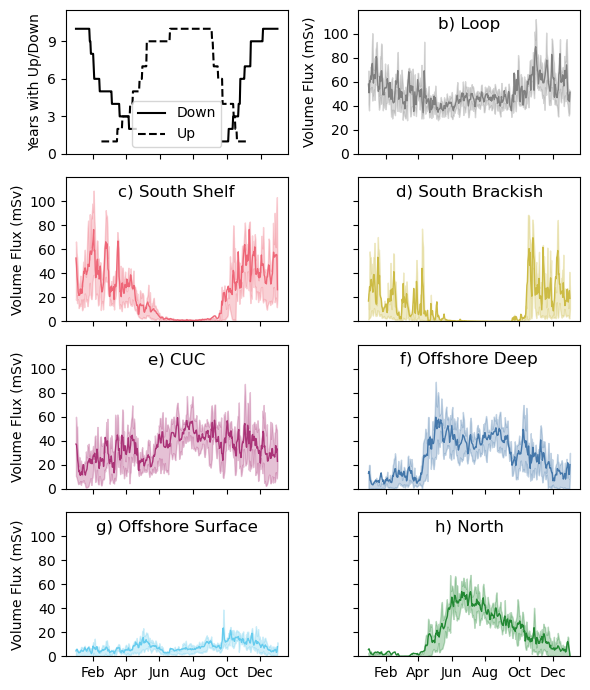

In [20]:
# plot data mean with range using quartiles
ymax=120000

fig, ax = plt.subplots(4,2, figsize=(6,7))

for axs in [ax[0,1],ax[1,0],ax[2,0],ax[3,0]]:
    axs.set_yticks([0,20000,40000,60000,80000,100000])
    axs.set_yticklabels(['0','20','40','60','80','100'])
    axs.set_ylabel('Volume Flux (mSv)')
for axs in [ax[1,1],ax[2,1],ax[3,1]]:
    axs.set_yticks([0,20000,40000,60000,80000,100000])
    axs.set_yticklabels([])

for i in range(4):
    for axs in ax[i]:
        axs.set_xticks([397-365,456-365,152,213,274,335]) #february 1, april 1, october 1, december 1
ax[3,0].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])
ax[3,1].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])


# count of the number of summers and winters with this date in the range
split=109
ax[0,0].plot(DWcount.jday[:split],DWcount['count'][:split],'k',label='Down')
ax[0,0].plot(DWcount.jday[split:],DWcount['count'][split:],'k')
ax[0,0].plot(UPcount.jday,UPcount['count'],'k--',label='Up')
ax[0,0].set_ylim([0,11.5])
ax[0,0].set_yticks([0,3,6,9])
ax[0,0].set_xticklabels([])
ax[0,0].set_ylabel("Years with Up/Down")
ax[0,0].legend()

# loop flow
ax[0,1].plot(loop.index.values,loop['mean'],'grey',lw=1)
ax[0,1].fill_between(loop.index.values,
                        loop.quart25,
                        loop.quart75,
                        color='grey',alpha=0.3)
ax[0,1].set_xticklabels([])
ax[0,1].set_ylim([0,ymax])
ax[0,1].set_title('b) Loop',y=1,pad=-14)

# south shelf flow
ax[1,0].plot(south.index.values,south['mean'],'#EE6677',lw=1)
ax[1,0].fill_between(south.index.values,
                        south.quart25,
                        south.quart75,
                        color='#EE6677',alpha=0.3)
ax[1,0].set_xticklabels([])
ax[1,0].set_ylim([0,ymax])
ax[1,0].set_title('c) South Shelf',y=1,pad=-14)


# fresh flow
ax[1,1].plot(fresh.index.values,fresh['mean'],'#CCBB44',lw=1)
ax[1,1].fill_between(fresh.index.values,
                        fresh.quart25,
                        fresh.quart75,
                        color='#CCBB44',alpha=0.3)
ax[1,1].set_yticklabels([])
ax[1,1].set_xticklabels([])
ax[1,1].set_ylim([0,ymax])
ax[1,1].set_title('d) South Brackish',y=1,pad=-14)

# cuc flow
ax[2,0].plot(cuc.index.values,cuc['mean'],'#AA3377',lw=1)
ax[2,0].fill_between(cuc.index.values,
                        cuc.quart25,
                        cuc.quart75,
                        color='#AA3377',alpha=0.3)
ax[2,0].set_xticklabels([])
ax[2,0].set_ylim([0,ymax])
ax[2,0].set_title('e) CUC',y=1,pad=-14)

# offshore deep flow
ax[2,1].plot(offd.index.values,offd['mean'],'#4477AA',lw=1)
ax[2,1].fill_between(offd.index.values,
                        offd.quart25,
                        offd.quart75,
                        color='#4477AA',alpha=0.3)
ax[2,1].set_ylim([0,ymax])
ax[2,1].set_title('f) Offshore Deep',y=1,pad=-14)
ax[2,1].set_yticklabels([])
ax[2,1].set_xticklabels([])

# offshore surface flow
ax[3,0].plot(offs.index.values,offs['mean'],'#66CCEE',lw=1)
ax[3,0].fill_between(offs.index.values,
                        offs.quart25,
                        offs.quart75,
                        color='#66CCEE',alpha=0.3)
# ax[3,0].set_xticklabels([])
ax[3,0].set_ylim([0,ymax])
ax[3,0].set_title('g) Offshore Surface',y=1,pad=-14)


# north flow
ax[3,1].plot(north.index.values,north['mean'],'#228833',lw=1)
ax[3,1].fill_between(north.index.values,
                        north.quart25,
                        north.quart75,
                        color='#228833',alpha=0.3)
ax[3,1].set_ylim([0,ymax])
ax[3,1].set_title('h) North',y=1,pad=-14)
ax[3,1].set_yticklabels([])


# # add letter markers to each figure 
# ax[0,0].text(.03, .05, 'a)', ha='left', va='bottom', transform=ax[0,0].transAxes, fontsize=12)



plt.tight_layout()
# plt.savefig('./figures/total_dynamics.pdf')

In [21]:
# total flow
total = loop+offd+offs+north+south+cuc+fresh
col = ['transport_2014','transport_2015','transport_2016','transport_2017','transport_2018','transport_2019','transport_2020','transport_2021','transport_2022','transport_2023']
mean = [np.mean(total.loc[i+1,col]) for i in range(len(total))]
quart25 = [total.loc[i+1,col].agg(lambda x: x.quantile(0.25)) for i in range(len(total))]
quart75 = [total.loc[i+1,col].agg(lambda x: x.quantile(0.75)) for i in range(len(total))]

total['mean'] = mean
total['quart25'] = quart25
total['quart75'] = quart75

In [22]:
total

,transport_2014,transport_2015,transport_2016,transport_2017,transport_2018,transport_2019,transport_2020,transport_2021,transport_2022,transport_2023,mean,quart25,quart75
yearday,,,,,,,,,,,,,
1,102519.114382,233260.520673,146965.635455,269359.939118,213335.004628,225538.181155,100158.364498,155649.094505,291672.044687,145218.839084,188367.673818,145655.538177,231329.935793
2,54086.345227,198020.317934,126770.369582,322822.913172,237487.012930,132342.711621,129401.728177,163271.921355,331631.598175,133737.763358,182957.268153,130136.974038,227620.339181
3,85287.905725,190323.617483,147520.929158,284748.419875,246988.687063,101007.878704,197892.104270,163804.448841,287023.760868,106787.260336,181138.501232,116970.677542,234714.541365
4,132341.002080,150525.708482,137798.381932,220141.981711,175410.870364,140892.643932,133922.958830,140460.520272,222760.337294,106838.418198,156109.282309,134891.814606,169189.579893
5,151725.788794,129539.123124,153244.886327,203404.307126,135432.040899,128532.500646,116533.740411,172100.282143,200140.237965,144512.298860,153516.520629,131012.352568,167386.433189
...,...,...,...,...,...,...,...,...,...,...,...,...,...
362,147431.103455,254882.567067,129172.174778,98762.455078,197734.694829,173761.358439,272953.286931,93993.953789,430074.045345,141115.185630,193988.082534,132157.927491,240595.599008
363,134134.253953,347639.827152,161074.652484,115876.316807,216398.176154,105007.911798,223276.904099,91242.811035,362021.876369,125634.095683,188230.682553,118315.761526,221557.222112
364,135956.536392,259623.470341,169117.008665,76836.463810,207169.765100,202639.287864,87986.885180,144198.315486,327826.039561,196290.751148,180764.452355,138016.981166,206037.145791


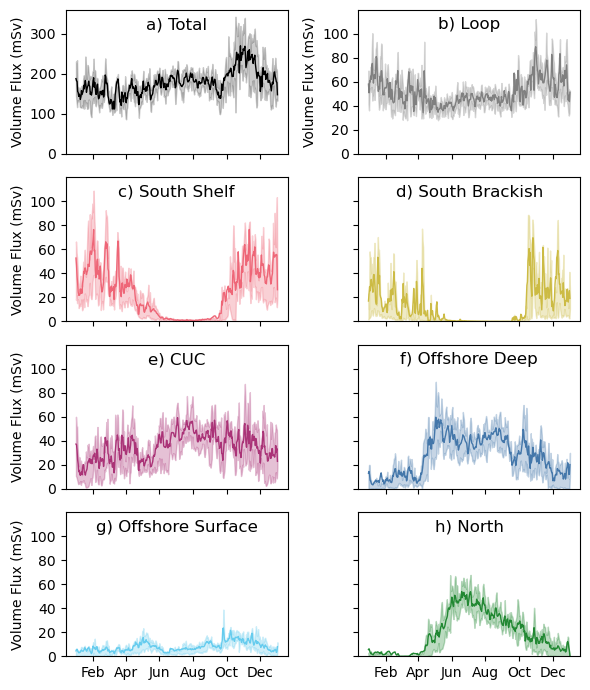

In [23]:
# plot data mean with range using quartiles
ymax=120000

fig, ax = plt.subplots(4,2, figsize=(6,7))

for axs in [ax[0,1],ax[1,0],ax[2,0],ax[3,0]]:
    axs.set_yticks([0,20000,40000,60000,80000,100000])
    axs.set_yticklabels(['0','20','40','60','80','100'])
    axs.set_ylabel('Volume Flux (mSv)')
for axs in [ax[1,1],ax[2,1],ax[3,1]]:
    axs.set_yticks([0,20000,40000,60000,80000,100000])
    axs.set_yticklabels([])

ax[0,0].set_yticks([0,100000,200000,300000])
ax[0,0].set_yticklabels(['0','100','200','300'])
ax[0,0].set_ylabel('Volume Flux (mSv)')

for i in range(4):
    for axs in ax[i]:
        axs.set_xticks([397-365,456-365,152,213,274,335]) #february 1, april 1, october 1, december 1
ax[3,0].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])
ax[3,1].set_xticklabels(['Feb','Apr','Jun','Aug','Oct','Dec'])


# total flow
ax[0,0].plot(total.index.values,total['mean'],'k',lw=1)
ax[0,0].fill_between(total.index.values,
                        total.quart25,
                        total.quart75,
                        color='k',alpha=0.2)
ax[0,0].set_xticklabels([])
ax[0,0].set_ylim([0,360000])
ax[0,0].set_title('a) Total',y=1,pad=-14)

# loop flow
ax[0,1].plot(loop.index.values,loop['mean'],'grey',lw=1)
ax[0,1].fill_between(loop.index.values,
                        loop.quart25,
                        loop.quart75,
                        color='grey',alpha=0.3)
ax[0,1].set_xticklabels([])
ax[0,1].set_ylim([0,ymax])
ax[0,1].set_title('b) Loop',y=1,pad=-14)

# south shelf flow
ax[1,0].plot(south.index.values,south['mean'],'#EE6677',lw=1)
ax[1,0].fill_between(south.index.values,
                        south.quart25,
                        south.quart75,
                        color='#EE6677',alpha=0.3)
ax[1,0].set_xticklabels([])
ax[1,0].set_ylim([0,ymax])
ax[1,0].set_title('c) South Shelf',y=1,pad=-14)


# fresh flow
ax[1,1].plot(fresh.index.values,fresh['mean'],'#CCBB44',lw=1)
ax[1,1].fill_between(fresh.index.values,
                        fresh.quart25,
                        fresh.quart75,
                        color='#CCBB44',alpha=0.3)
ax[1,1].set_yticklabels([])
ax[1,1].set_xticklabels([])
ax[1,1].set_ylim([0,ymax])
ax[1,1].set_title('d) South Brackish',y=1,pad=-14)

# cuc flow
ax[2,0].plot(cuc.index.values,cuc['mean'],'#AA3377',lw=1)
ax[2,0].fill_between(cuc.index.values,
                        cuc.quart25,
                        cuc.quart75,
                        color='#AA3377',alpha=0.3)
ax[2,0].set_xticklabels([])
ax[2,0].set_ylim([0,ymax])
ax[2,0].set_title('e) CUC',y=1,pad=-14)

# offshore deep flow
ax[2,1].plot(offd.index.values,offd['mean'],'#4477AA',lw=1)
ax[2,1].fill_between(offd.index.values,
                        offd.quart25,
                        offd.quart75,
                        color='#4477AA',alpha=0.3)
ax[2,1].set_ylim([0,ymax])
ax[2,1].set_title('f) Offshore Deep',y=1,pad=-14)
ax[2,1].set_yticklabels([])
ax[2,1].set_xticklabels([])

# offshore surface flow
ax[3,0].plot(offs.index.values,offs['mean'],'#66CCEE',lw=1)
ax[3,0].fill_between(offs.index.values,
                        offs.quart25,
                        offs.quart75,
                        color='#66CCEE',alpha=0.3)
# ax[3,0].set_xticklabels([])
ax[3,0].set_ylim([0,ymax])
ax[3,0].set_title('g) Offshore Surface',y=1,pad=-14)


# north flow
ax[3,1].plot(north.index.values,north['mean'],'#228833',lw=1)
ax[3,1].fill_between(north.index.values,
                        north.quart25,
                        north.quart75,
                        color='#228833',alpha=0.3)
ax[3,1].set_ylim([0,ymax])
ax[3,1].set_title('h) North',y=1,pad=-14)
ax[3,1].set_yticklabels([])


# # add letter markers to each figure 
# ax[0,0].text(.03, .05, 'a)', ha='left', va='bottom', transform=ax[0,0].transAxes, fontsize=12)



plt.tight_layout()
plt.savefig('./figures/total_dynamics.pdf')